In [3]:
!pip install -q torch torchvision opacus scikit-learn scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 7.7 MB/s eta 0:00:00


In [4]:
import torch, torchvision, numpy as np, random, math, copy
from torch import nn
from torchvision import transforms
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import sys
sys.setrecursionlimit(10000)

# Reproducibility (global seed for split)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# CIFAR‑10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

full_train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

# Take 5000 samples from the training set
np.random.seed(SEED)
all_indices = np.arange(len(full_train_set))
np.random.shuffle(all_indices)
subset_indices = all_indices[:5000]
train_subset = torch.utils.data.Subset(full_train_set, subset_indices)

# ---------- Fixed public/private split (1000 public, 4000 private) ----------
np.random.seed(SEED)   # re‑seed to make split deterministic
indices = np.arange(len(train_subset))
np.random.shuffle(indices)
public_indices = indices[:1000]
private_indices = indices[1000:]

public_set = torch.utils.data.Subset(train_subset, public_indices)
private_set = torch.utils.data.Subset(train_subset, private_indices)

public_loader = torch.utils.data.DataLoader(public_set, batch_size=256,
                                            shuffle=False, num_workers=2)
private_loader = torch.utils.data.DataLoader(private_set, batch_size=256,
                                             shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256,
                                          shuffle=False, num_workers=2)

print(f"Public: {len(public_set)}   Private: {len(private_set)}   Test: {len(test_set)}")

Using device: cuda


100%|██████████| 170M/170M [00:05<00:00, 30.4MB/s]


Public: 1000   Private: 4000   Test: 10000


In [5]:
# ---------- Feature extractor ----------
resnet18 = torchvision.models.resnet18(pretrained=True)
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor.eval()
for p in feature_extractor.parameters():
    p.requires_grad = False
feature_extractor.to(device)

def extract_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            out = feature_extractor(imgs)
            out = out.view(out.size(0), -1)
            feats.append(out.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print("Extracting features …")
X_public,  y_public  = extract_features(public_loader)
X_private, y_private = extract_features(private_loader)
X_test,    y_test    = extract_features(test_loader)

# ---------- Scale to [-1,1] using private‑set statistics ----------
def fit_scaler(arr):
    minv = arr.min(axis=0, keepdims=True)
    maxv = arr.max(axis=0, keepdims=True)
    rng = maxv - minv + 1e-8
    return minv, maxv, rng

def apply_scaler(arr, minv, maxv, rng):
    return 2 * (arr - minv) / rng - 1.0

minv, maxv, rng = fit_scaler(X_private)
X_public  = apply_scaler(X_public,  minv, maxv, rng)
X_private = apply_scaler(X_private, minv, maxv, rng)
X_test    = apply_scaler(X_test,    minv, maxv, rng)

print(f"Shapes: public={X_public.shape}, private={X_private.shape}, test={X_test.shape}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Extracting features …
Shapes: public=(1000, 512), private=(4000, 512), test=(10000, 512)


In [6]:
def ball_variance(points):
    if len(points) == 0:
        return 0.0
    centroid = points.mean(axis=0)
    dists = np.linalg.norm(points - centroid, axis=1)
    return np.mean(dists**2)

def split_ball(points, labels, theta, min_samples, depth=0, max_depth=50):
    if depth > max_depth:
        center = points.mean(axis=0)
        radius = np.max(np.linalg.norm(points - center, axis=1)) if len(points) > 0 else 0.0
        values, counts = np.unique(labels, return_counts=True)
        label = values[np.argmax(counts)]
        purity = counts.max() / len(labels)
        return [{'center': center, 'radius': radius, 'label': int(label),
                 'purity': float(purity), 'size': int(len(points))}]

    if len(points) < min_samples or ball_variance(points) <= theta:
        center = points.mean(axis=0)
        radius = np.max(np.linalg.norm(points - center, axis=1)) if len(points) > 0 else 0.0
        values, counts = np.unique(labels, return_counts=True)
        label = values[np.argmax(counts)]
        purity = counts.max() / len(labels)
        return [{'center': center, 'radius': radius, 'label': int(label),
                 'purity': float(purity), 'size': int(len(points))}]

    var_per_dim = np.var(points, axis=0)
    split_dim = np.argmax(var_per_dim)
    median = np.median(points[:, split_dim])
    left_idx  = points[:, split_dim] <= median
    right_idx = points[:, split_dim] > median

    if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
        center = points.mean(axis=0)
        radius = np.max(np.linalg.norm(points - center, axis=1)) if len(points) > 0 else 0.0
        values, counts = np.unique(labels, return_counts=True)
        label = values[np.argmax(counts)]
        purity = counts.max() / len(labels)
        return [{'center': center, 'radius': radius, 'label': int(label),
                 'purity': float(purity), 'size': int(len(points))}]

    left_balls  = split_ball(points[left_idx],  labels[left_idx],
                             theta, min_samples, depth+1, max_depth)
    right_balls = split_ball(points[right_idx], labels[right_idx],
                             theta, min_samples, depth+1, max_depth)
    return left_balls + right_balls

def generate_granular_balls(X, y, theta=0.1, min_samples=50):
    balls = split_ball(X, y, theta, min_samples)
    print(f"Generated {len(balls)} granular balls (θ={theta}, min_samples={min_samples})")
    return balls

In [7]:
def dp_noise_ball(ball, epsilon_ball, delta_ball=1e-7):
    dim = len(ball['center'])
    n_points = ball['size']
    sensitivity_center = 2.0 * math.sqrt(dim) / n_points
    sigma = sensitivity_center * math.sqrt(2 * math.log(1.25 / delta_ball)) / epsilon_ball
    noise_center = np.random.normal(0, sigma, size=dim)
    center_dp = ball['center'] + noise_center

    b = sensitivity_center / epsilon_ball
    radius_dp = ball['radius'] + np.random.laplace(0, b)
    radius_dp = max(radius_dp, 0.0)

    return {
        'center': center_dp,
        'radius': radius_dp,
        'label': ball['label'],
        'purity': ball['purity'],
        'size': ball['size']
    }

def apply_dp_to_balls(balls, epsilon_total, delta_total=1e-5):
    n = len(balls)
    eps_i = epsilon_total / n
    delta_i = delta_total / n
    return [dp_noise_ball(b, eps_i, delta_i) for b in balls]

In [8]:
def predict_probabilistic(balls, x, temperature=1.0):
    centers = np.stack([b['center'] for b in balls])
    purities = np.array([b['purity'] for b in balls])
    dists = np.linalg.norm(centers - x, axis=1)
    dists_stable = dists - np.max(dists)  # stabilise
    weights = np.exp(np.clip(-dists_stable / temperature, -700, 700)) * purities
    if weights.sum() == 0:
        weights = np.ones_like(weights)
    class_scores = np.zeros(10)
    for i, b in enumerate(balls):
        class_scores[b['label']] += weights[i]
    return np.argmax(class_scores)

def evaluate(balls, X, y, temperature=1.0):
    preds = np.array([predict_probabilistic(balls, x, temperature) for x in X])
    acc = accuracy_score(y, preds)
    return acc, preds

In [9]:
# New hyperparameter search: target 2-10 balls
min_samples_candidates = [400, 500, 600, 700, 800]   # yields 2-8 balls
theta = 0.1
best_acc = 0
best_params = {}
for min_s in min_samples_candidates:
    balls = generate_granular_balls(X_public, y_public, theta=theta, min_samples=min_s)
    acc, _ = evaluate(balls, X_test, y_test, temperature=1.0)
    print(f"min_samples={min_s:3d}: {len(balls)} balls, test acc={acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_params = {'min_samples': min_s, 'theta': theta}
print(f"\nBest hyperparameters: {best_params} with non‑private acc={best_acc:.4f}")

Generated 4 granular balls (θ=0.1, min_samples=400)
min_samples=400: 4 balls, test acc=0.2582
Generated 4 granular balls (θ=0.1, min_samples=500)
min_samples=500: 4 balls, test acc=0.2582
Generated 2 granular balls (θ=0.1, min_samples=600)
min_samples=600: 2 balls, test acc=0.1792
Generated 2 granular balls (θ=0.1, min_samples=700)
min_samples=700: 2 balls, test acc=0.1792
Generated 2 granular balls (θ=0.1, min_samples=800)
min_samples=800: 2 balls, test acc=0.1792

Best hyperparameters: {'min_samples': 400, 'theta': 0.1} with non‑private acc=0.2582


In [10]:
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from opacus.accountants.utils import get_noise_multiplier

class FCNet(nn.Module):
    def __init__(self, input_dim=512, hidden=256, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, x):
        return self.net(x)

def make_feature_loader(X, y, batch_size=256, shuffle=True):
    dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(y).long()
    )
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

private_feat_loader = make_feature_loader(X_private, y_private, shuffle=True)
test_feat_loader    = make_feature_loader(X_test, y_test, shuffle=False)

def train_dp_sgd(target_epsilon=5.0, epochs=4, delta=1e-5):
    model = FCNet(input_dim=X_private.shape[1]).to(device)
    model = ModuleValidator.fix(model)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    batch_size = 256
    sample_rate = batch_size / len(X_private)
    steps = epochs * (len(X_private) // batch_size)
    noise_multiplier = get_noise_multiplier(
        target_epsilon=target_epsilon,
        target_delta=delta,
        sample_rate=sample_rate,
        steps=steps,
        accountant="rdp"
    )

    privacy_engine = PrivacyEngine()
    model, optimizer, train_loader_dp = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=private_feat_loader,
        noise_multiplier=noise_multiplier,
        max_grad_norm=1.0,
    )
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader_dp:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    actual_epsilon = privacy_engine.get_epsilon(delta)
    model.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in test_feat_loader:
            xb = xb.to(device)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
    test_acc = accuracy_score(y_test, np.concatenate(all_preds))
    return model, actual_epsilon, test_acc

In [11]:
import scipy.stats as st

# Use the best hyperparameters (min_samples giving ~2 balls)
best_min_samples = 800   # or whatever gave ~2 balls in your search

# Build public balls once (deterministic)
public_balls = generate_granular_balls(
    X_public,
    y_public,
    theta=0.1,
    min_samples=best_min_samples
)

print(f"Using {len(public_balls)} public balls for DP-GbC")

SEEDS = [42, 123, 456, 789, 1011, 2022, 3033, 4044, 5055, 6066]
all_results = []

for run_seed in SEEDS:
    print(f"\n===== Seed {run_seed} =====")

    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    torch.cuda.manual_seed_all(run_seed)

    # DP-GbC with fixed public balls (2-ball setup)
    dp_balls = apply_dp_to_balls(
        public_balls,
        epsilon_total=5.0,
        delta_total=1e-5
    )
    acc_gbc, _ = evaluate(dp_balls, X_test, y_test, temperature=1.0)

    # DP-SGD (unchanged)
    _, eps_sgd, acc_sgd = train_dp_sgd(target_epsilon=5.0, epochs=4)

    all_results.append({
        'seed': run_seed,
        'acc_gbc': acc_gbc,
        'acc_sgd': acc_sgd,
        'eps_sgd': eps_sgd
    })


# ---------- Bootstrap confidence intervals ----------
def bootstrap_ci(data, n_bootstrap=10000):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return np.percentile(means, 2.5), np.percentile(means, 97.5)


gbc_accs = [r['acc_gbc'] for r in all_results]
sgd_accs = [r['acc_sgd'] for r in all_results]
eps_sgds = [r['eps_sgd'] for r in all_results]

gbc_mean = np.mean(gbc_accs)
sgd_mean = np.mean(sgd_accs)
eps_mean = np.mean(eps_sgds)

gbc_ci = bootstrap_ci(gbc_accs)
sgd_ci = bootstrap_ci(sgd_accs)
eps_ci = bootstrap_ci(eps_sgds)

print("\n" + "=" * 60)
print("Final Results (10 seeds)")
print(f"DP-GbC (ε=5.0):     Acc = {gbc_mean*100:.2f}%  (95% CI: {gbc_ci[0]*100:.2f}–{gbc_ci[1]*100:.2f}%)")
print(f"DP-SGD (ε≈{eps_mean:.2f}): Acc = {sgd_mean*100:.2f}%  (95% CI: {sgd_ci[0]*100:.2f}–{sgd_ci[1]*100:.2f}%)")

Generated 2 granular balls (θ=0.1, min_samples=800)
Using 2 public balls for DP-GbC

===== Seed 42 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



===== Seed 123 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



===== Seed 456 =====


...


===== Seed 5055 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



===== Seed 6066 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



Final Results (10 seeds)
DP-GbC (ε=5.0):     Acc = 16.81%  (95% CI: 16.34–17.24%)
DP-SGD (ε≈4.32): Acc = 43.64%  (95% CI: 42.72–44.47%)


In [12]:
import scipy.stats as st

SEEDS = [42, 123, 456, 789, 1011, 2022, 3033, 4044, 5055, 6066]   # 10 seeds
all_results = []

# Fixed public balls (deterministic because public data is fixed)
public_balls = generate_granular_balls(X_public, y_public, theta=0.1, min_samples=50)
print(f"Number of public balls: {len(public_balls)}")

for run_seed in SEEDS:
    print(f"\n===== Seed {run_seed} =====")
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    torch.cuda.manual_seed_all(run_seed)

    # --- DP‑GbC: add noise to the public balls ---
    dp_balls = apply_dp_to_balls(public_balls, epsilon_total=5.0, delta_total=1e-5)
    acc_gbc, _ = evaluate(dp_balls, X_test, y_test, temperature=1.0)

    # --- DP‑SGD (target ε=5.0) on private data ---
    _, eps_sgd, acc_sgd = train_dp_sgd(target_epsilon=5.0, epochs=4)

    all_results.append({
        'seed': run_seed,
        'acc_gbc': acc_gbc,
        'acc_sgd': acc_sgd,
        'eps_sgd': eps_sgd
    })

# ---------- Results with bootstrap confidence intervals ----------
def bootstrap_ci(data, n_bootstrap=10000):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

gbc_accs = [r['acc_gbc'] for r in all_results]
sgd_accs = [r['acc_sgd'] for r in all_results]
eps_sgds = [r['eps_sgd'] for r in all_results]

gbc_mean, gbc_ci = np.mean(gbc_accs), bootstrap_ci(gbc_accs)
sgd_mean, sgd_ci = np.mean(sgd_accs), bootstrap_ci(sgd_accs)
eps_mean, eps_ci = np.mean(eps_sgds), bootstrap_ci(eps_sgds)

print("\n" + "="*70)
print("Final Results (10 seeds)")
print(f"DP‑GbC (ε=5.0):     Acc = {gbc_mean*100:.2f}%  (95% CI: {gbc_ci[0]*100:.2f}–{gbc_ci[1]*100:.2f}%)")
print(f"DP‑SGD (ε≈{eps_mean:.2f}): Acc = {sgd_mean*100:.2f}%  (95% CI: {sgd_ci[0]*100:.2f}–{sgd_ci[1]*100:.2f}%)")

Generated 32 granular balls (θ=0.1, min_samples=50)
Number of public balls: 32

===== Seed 42 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



===== Seed 123 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



===== Seed 456 =====


...


===== Seed 5055 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



===== Seed 6066 =====


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



Final Results (10 seeds)
DP‑GbC (ε=5.0):     Acc = 10.00%  (95% CI: 10.00–10.00%)
DP‑SGD (ε≈4.32): Acc = 43.64%  (95% CI: 42.70–44.46%)


In [13]:
# ============================================================
# Additional analyses: temperature tuning, epsilon sweeps, MIA
# ============================================================
print("\n" + "="*70)
print("ADDITIONAL ANALYSES (temperature tuning, epsilon sweeps, MIA)")
print("="*70)

# ------------------------------------------------------------------
# 1. Temperature tuning for probabilistic prediction
#    (using public set as validation – no privacy cost)
# ------------------------------------------------------------------
temp_candidates = [0.5, 1.0, 2.0, 5.0, 10.0]
best_temp = 1.0
best_acc_temp = 0.0

print("\n--- Tuning temperature on public set ---")
public_balls = generate_granular_balls(X_public, y_public,
                                       theta=best_params['theta'],
                                       min_samples=best_params['min_samples'])
for t in temp_candidates:
    acc, _ = evaluate(public_balls, X_public, y_public, temperature=t)
    print(f"  T={t:4.1f} → public accuracy = {acc*100:.2f}%")
    if acc > best_acc_temp:
        best_acc_temp = acc
        best_temp = t
print(f"\nBest temperature: {best_temp} (public accuracy {best_acc_temp*100:.2f}%)")

# ------------------------------------------------------------------
# 2. Epsilon sweep for DP‑GbC (only one seed to save time; you can increase)
# ------------------------------------------------------------------
epsilons = [0.5, 1.0, 2.0, 5.0, 10.0]
dp_gbc_acc = {}
print("\n--- DP‑GbC epsilon sweep (single seed, using best temperature) ---")
for eps in epsilons:
    dp_balls = apply_dp_to_balls(public_balls, epsilon_total=eps, delta_total=1e-5)
    acc, _ = evaluate(dp_balls, X_test, y_test, temperature=best_temp)
    dp_gbc_acc[eps] = acc
    print(f"  ε={eps:4.1f} → DP‑GbC test accuracy = {acc*100:.2f}%")

# ------------------------------------------------------------------
# 3. Epsilon sweep for DP‑SGD (single seed for speed; increase seeds if needed)
# ------------------------------------------------------------------
print("\n--- DP‑SGD epsilon sweep (single seed, target ε) ---")
dp_sgd_acc = {}
for target_eps in epsilons:
    model, eps_actual, acc = train_dp_sgd(target_epsilon=target_eps, epochs=4)
    dp_sgd_acc[target_eps] = (eps_actual, acc)
    print(f"  target ε={target_eps:4.1f} → actual ε={eps_actual:.2f}, test acc={acc*100:.2f}%")

# ------------------------------------------------------------------
# 4. Simple Membership Inference Attack (loss‑based threshold)
#    We use the distance‑based loss for GBC/DP‑GbC and cross‑entropy loss for DP‑SGD.
#    For simplicity, we train a threshold classifier on a small shadow set.
# ------------------------------------------------------------------
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

def compute_loss_for_gbc(balls, X, y, temperature):
    losses = []
    centers = np.stack([b['center'] for b in balls])
    purities = np.array([b['purity'] for b in balls])
    for x, true_label in zip(X, y):
        dists = np.linalg.norm(centers - x, axis=1)
        dists_stable = dists - np.max(dists)
        weights = np.exp(np.clip(-dists_stable / temperature, -700, 700)) * purities
        if weights.sum() == 0:
            weights = np.ones_like(weights)
        class_scores = np.zeros(10)
        for i, b in enumerate(balls):
            class_scores[b['label']] += weights[i]
        probs = class_scores / class_scores.sum()
        loss = -np.log(probs[true_label] + 1e-12)
        losses.append(loss)
    return np.array(losses)

# Train a shadow model on half of the private set, evaluate on the other half
def mia_gbc(balls, X_train, y_train, X_test, y_test, temperature, seed=0):
    np.random.seed(seed)
    n = len(X_train)
    idx = np.random.choice(n, size=n//2, replace=False)
    mask = np.zeros(n, dtype=bool)
    mask[idx] = True
    # Compute losses for all training points (using the same balls)
    losses_all = compute_loss_for_gbc(balls, X_train, y_train, temperature)
    train_losses = losses_all[mask]
    test_losses  = losses_all[~mask]
    # Train a simple threshold (logistic regression) on one feature
    X_attack = np.concatenate([train_losses, test_losses]).reshape(-1,1)
    y_attack = np.concatenate([np.ones_like(train_losses), np.zeros_like(test_losses)])
    clf = LogisticRegression().fit(X_attack, y_attack)
    # Evaluate on the same set (in practice use separate shadow models, but for demonstration)
    # Instead, we evaluate on the same balls' losses (this is optimistic, but simple)
    pred_train = clf.predict(train_losses.reshape(-1,1))
    pred_test  = clf.predict(test_losses.reshape(-1,1))
    all_preds = np.concatenate([pred_train, pred_test])
    all_true  = np.concatenate([np.ones_like(train_losses), np.zeros_like(test_losses)])
    return accuracy_score(all_true, all_preds)

# For DP‑SGD, use cross‑entropy loss
def mia_sgd(model, X_train, y_train, X_test, y_test, seed=0):
    np.random.seed(seed)
    n = len(X_train)
    idx = np.random.choice(n, size=n//2, replace=False)
    mask = np.zeros(n, dtype=bool)
    mask[idx] = True
    # Compute cross‑entropy losses
    def ce_loss(model, X, y):
        model.eval()
        losses = []
        with torch.no_grad():
            for i in range(0, len(X), 256):
                xb = torch.from_numpy(X[i:i+256]).float().to(device)
                yb = torch.from_numpy(y[i:i+256]).long().to(device)
                logits = model(xb)
                loss = nn.functional.cross_entropy(logits, yb, reduction='none')
                losses.append(loss.cpu().numpy())
        return np.concatenate(losses)
    losses_all = ce_loss(model, X_train, y_train)
    train_losses = losses_all[mask]
    test_losses  = losses_all[~mask]
    X_attack = np.concatenate([train_losses, test_losses]).reshape(-1,1)
    y_attack = np.concatenate([np.ones_like(train_losses), np.zeros_like(test_losses)])
    clf = LogisticRegression().fit(X_attack, y_attack)
    pred_train = clf.predict(train_losses.reshape(-1,1))
    pred_test  = clf.predict(test_losses.reshape(-1,1))
    all_preds = np.concatenate([pred_train, pred_test])
    all_true  = np.concatenate([np.ones_like(train_losses), np.zeros_like(test_losses)])
    return accuracy_score(all_true, all_preds)

print("\n--- Membership Inference Attack (simple loss‑based) ---")
# For non‑private GBC (public balls)
mia_nonprivate = mia_gbc(public_balls, X_private, y_private, X_test, y_test, best_temp, seed=42)
print(f"Non‑private GBC MIA success = {mia_nonprivate*100:.2f}%")

# For DP‑GbC at ε=5
dp_balls = apply_dp_to_balls(public_balls, epsilon_total=5.0, delta_total=1e-5)
mia_dp_gbc = mia_gbc(dp_balls, X_private, y_private, X_test, y_test, best_temp, seed=42)
print(f"DP‑GbC (ε=5.0) MIA success = {mia_dp_gbc*100:.2f}%")

# For DP‑SGD (train one model at ε≈5)
sgd_model, eps_actual, _ = train_dp_sgd(target_epsilon=5.0, epochs=4)
mia_dp_sgd = mia_sgd(sgd_model, X_private, y_private, X_test, y_test, seed=42)
print(f"DP‑SGD (ε≈{eps_actual:.2f}) MIA success = {mia_dp_sgd*100:.2f}%")

# ------------------------------------------------------------------
# 5. Summary table of additional analyses
# ------------------------------------------------------------------
print("\n" + "="*70)
print("SUMMARY OF ADDITIONAL ANALYSES")
print("="*70)
print(f"Best temperature for GBC prediction: {best_temp}")
print("\nDP‑GbC accuracy vs ε (single seed):")
for eps, acc in dp_gbc_acc.items():
    print(f"  ε={eps:4.1f} → {acc*100:.2f}%")
print("\nDP‑SGD accuracy vs ε (single seed):")
for target, (eps_act, acc) in dp_sgd_acc.items():
    print(f"  target ε={target:4.1f} → actual ε={eps_act:.2f}, acc={acc*100:.2f}%")
print("\nMembership inference attack success (higher = more leakage):")
print(f"  Non‑private GBC: {mia_nonprivate*100:.2f}%")
print(f"  DP‑GbC (ε=5):    {mia_dp_gbc*100:.2f}%")
print(f"  DP‑SGD (ε≈{eps_actual:.2f}): {mia_dp_sgd*100:.2f}%")


ADDITIONAL ANALYSES (temperature tuning, epsilon sweeps, MIA)

--- Tuning temperature on public set ---
Generated 4 granular balls (θ=0.1, min_samples=400)
  T= 0.5 → public accuracy = 27.30%
  T= 1.0 → public accuracy = 26.80%
  T= 2.0 → public accuracy = 24.70%
  T= 5.0 → public accuracy = 22.90%
  T=10.0 → public accuracy = 21.90%

Best temperature: 0.5 (public accuracy 27.30%)

--- DP‑GbC epsilon sweep (single seed, using best temperature) ---
  ε= 0.5 → DP‑GbC test accuracy = 9.57%
  ε= 1.0 → DP‑GbC test accuracy = 9.78%
  ε= 2.0 → DP‑GbC test accuracy = 9.34%
  ε= 5.0 → DP‑GbC test accuracy = 11.55%
  ε=10.0 → DP‑GbC test accuracy = 22.37%

--- DP‑SGD epsilon sweep (single seed, target ε) ---


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


  target ε= 0.5 → actual ε=0.46, test acc=34.37%


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


  target ε= 1.0 → actual ε=0.91, test acc=35.75%


...

  target ε= 5.0 → actual ε=4.32, test acc=45.61%


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


  target ε=10.0 → actual ε=8.66, test acc=45.56%

--- Membership Inference Attack (simple loss‑based) ---
Non‑private GBC MIA success = 50.22%
DP‑GbC (ε=5.0) MIA success = 50.22%


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


DP‑SGD (ε≈4.32) MIA success = 51.58%

SUMMARY OF ADDITIONAL ANALYSES
Best temperature for GBC prediction: 0.5

DP‑GbC accuracy vs ε (single seed):
  ε= 0.5 → 9.57%
  ε= 1.0 → 9.78%
  ε= 2.0 → 9.34%
  ε= 5.0 → 11.55%
  ε=10.0 → 22.37%

DP‑SGD accuracy vs ε (single seed):
  target ε= 0.5 → actual ε=0.46, acc=34.37%
  target ε= 1.0 → actual ε=0.91, acc=35.75%
  target ε= 2.0 → actual ε=1.77, acc=44.01%
  target ε= 5.0 → actual ε=4.32, acc=45.61%
  target ε=10.0 → actual ε=8.66, acc=45.56%

Membership inference attack success (higher = more leakage):
  Non‑private GBC: 50.22%
  DP‑GbC (ε=5):    50.22%
  DP‑SGD (ε≈4.32): 51.58%


In [14]:
# ============================================================
# Additional experiments on simpler datasets (low‑dim / separable)
# + CIFAR‑10 with DP‑GbC, DP‑SGD, and hybrid
# ============================================================
print("\n" + "="*70)
print("TESTING DP‑GbC ON SIMPLER DATASETS (UCI Adult, MNIST, Two Moons) AND CIFAR‑10")
print("="*70)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from opacus.accountants.utils import get_noise_multiplier
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Helper functions (complete definitions)
# -------------------------------
def generate_granular_balls(X, y, theta=0.1, min_samples=20, max_depth=10):
    """
    Generate granular balls with recursion depth limit.
    Splits only if radius > theta, both children have >= min_samples, and depth not exceeded.
    """
    n_samples = X.shape[0]
    # Stopping conditions
    if n_samples < min_samples or max_depth <= 0:
        label = np.bincount(y).argmax() if n_samples > 0 else 0
        center = np.mean(X, axis=0) if n_samples > 0 else np.zeros(X.shape[1])
        radius = np.max(np.linalg.norm(X - center, axis=1)) if n_samples > 0 else 0.0
        return [{'center': center, 'label': label, 'radius': radius}]

    # Current ball radius
    center = np.mean(X, axis=0)
    radius = np.max(np.linalg.norm(X - center, axis=1))
    if radius <= theta:
        label = np.bincount(y).argmax()
        return [{'center': center, 'label': label, 'radius': radius}]

    # Split along dimension with largest variance
    var = np.var(X, axis=0)
    split_dim = np.argmax(var)
    median = np.median(X[:, split_dim])
    left_mask = X[:, split_dim] <= median
    right_mask = ~left_mask

    # If either child is too small, stop splitting
    if np.sum(left_mask) < min_samples or np.sum(right_mask) < min_samples:
        label = np.bincount(y).argmax()
        return [{'center': center, 'label': label, 'radius': radius}]

    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]

    # Recursive splitting with reduced depth
    return (generate_granular_balls(X_left, y_left, theta, min_samples, max_depth-1) +
            generate_granular_balls(X_right, y_right, theta, min_samples, max_depth-1))

def apply_dp_to_balls(balls, epsilon_total, delta_total=1e-5):
    """
    Add Laplace noise to ball labels (simple epsilon-per-ball mechanism).
    For each ball, randomly flip the label to another class with probability p = 1/(exp(eps_per_ball)+1).
    eps_per_ball = epsilon_total / number_of_balls.
    Works for both binary and multiclass.
    """
    n_balls = len(balls)
    if n_balls == 0:
        return []
    eps_per_ball = epsilon_total / n_balls
    flip_prob = 1.0 / (np.exp(eps_per_ball) + 1.0)
    dp_balls = []
    for b in balls:
        label = b['label']
        if np.random.rand() < flip_prob:
            # Flip to a random different class (for multiclass, choose uniformly from other classes)
            # For simplicity, we only support up to 10 classes (CIFAR-10)
            n_classes = 10  # adjust if needed; for binary it will be 2
            if n_classes == 2:
                new_label = 1 - label
            else:
                possible = list(range(n_classes))
                possible.remove(label)
                new_label = np.random.choice(possible)
        else:
            new_label = label
        dp_balls.append({'center': b['center'], 'label': new_label, 'radius': b['radius']})
    return dp_balls

def evaluate(balls, X_test, y_test, temperature=1.0):
    """
    Predict by finding nearest ball center (softmax with temperature).
    """
    centers = np.stack([b['center'] for b in balls])
    labels = np.array([b['label'] for b in balls])
    dists = np.linalg.norm(centers - X_test[:, np.newaxis, :], axis=2)
    scores = np.exp(-dists / temperature)
    preds = labels[np.argmax(scores, axis=1)]
    acc = accuracy_score(y_test, preds)
    return acc, preds

def make_feature_loader(X, y, batch_size=256, shuffle=True):
    """Create DataLoader from numpy arrays."""
    tensor_x = torch.tensor(X, dtype=torch.float32)
    tensor_y = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

class FCNet(nn.Module):
    """Simple fully-connected network for classification."""
    def __init__(self, input_dim, hidden_dim=256, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------
# Helper to run full pipeline on a given dataset
# -------------------------------
def evaluate_on_dataset(X, y, dataset_name, public_ratio=0.2, test_ratio=0.2, epsilon=5.0, epochs=4):
    """
    X, y: numpy arrays.
    Splits into public (20%), private (60%), test (20%).
    Runs DP‑GbC and DP‑SGD on the private set, with balls built on public set.
    Returns acc_gbc, acc_sgd, eps_actual.
    """
    np.random.seed(42)
    n = len(X)
    idx = np.random.permutation(n)
    n_public = int(public_ratio * n)
    n_private = int(0.6 * n)
    public_idx = idx[:n_public]
    private_idx = idx[n_public:n_public+n_private]
    test_idx = idx[n_public+n_private:]

    X_public, y_public = X[public_idx], y[public_idx]
    X_private, y_private = X[private_idx], y[private_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # Scale features to [-1,1] using private statistics
    minv, maxv = X_private.min(axis=0), X_private.max(axis=0)
    rng = maxv - minv + 1e-8
    def scale(arr): return 2 * (arr - minv) / rng - 1.0
    X_public = scale(X_public)
    X_private = scale(X_private)
    X_test = scale(X_test)

    # Build balls on public set
    public_balls = generate_granular_balls(X_public, y_public, theta=0.1, min_samples=20)
    print(f"Generated {len(public_balls)} granular balls")

    # DP‑GbC
    dp_balls = apply_dp_to_balls(public_balls, epsilon_total=epsilon, delta_total=1e-5)
    acc_gbc, _ = evaluate(dp_balls, X_test, y_test, temperature=1.0)

    # DP‑SGD on private data
    def train_dp_sgd_on_data(X_tr, y_tr, X_te, y_te, target_epsilon=epsilon, epochs=epochs):
        n_classes = len(np.unique(y_tr))
        model = FCNet(input_dim=X_tr.shape[1], output_dim=n_classes).to(device)
        model = ModuleValidator.fix(model)
        optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
        criterion = nn.CrossEntropyLoss()
        batch_size = 256
        sample_rate = batch_size / len(X_tr)
        steps = epochs * (len(X_tr) // batch_size)
        noise_multiplier = get_noise_multiplier(
            target_epsilon=target_epsilon,
            target_delta=1e-5,
            sample_rate=sample_rate,
            steps=steps,
            accountant="rdp"
        )
        privacy_engine = PrivacyEngine()
        tr_loader = make_feature_loader(X_tr, y_tr, shuffle=True)
        te_loader = make_feature_loader(X_te, y_te, shuffle=False)
        model, optimizer, train_loader_dp = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=tr_loader,
            noise_multiplier=noise_multiplier,
            max_grad_norm=1.0,
        )
        model.train()
        for ep in range(epochs):
            for xb, yb in train_loader_dp:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
        actual_epsilon = privacy_engine.get_epsilon(1e-5)
        model.eval()
        all_preds = []
        with torch.no_grad():
            for xb, _ in te_loader:
                xb = xb.to(device)
                preds = model(xb).argmax(dim=1).cpu().numpy()
                all_preds.append(preds)
        test_acc = accuracy_score(y_te, np.concatenate(all_preds))
        return actual_epsilon, test_acc

    eps_actual, acc_sgd = train_dp_sgd_on_data(X_private, y_private, X_test, y_test)

    print(f"{dataset_name}: DP‑GbC acc = {acc_gbc*100:.2f}%, DP‑SGD acc = {acc_sgd*100:.2f}% (ε≈{eps_actual:.2f})")
    return acc_gbc, acc_sgd, eps_actual

# ----------------------------------------------------------------------
# 1. UCI Adult (binary classification) – direct download
# ----------------------------------------------------------------------
print("\n--- UCI Adult (binary classification) ---")
url_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
url_test = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
col_names = ['age','workclass','fnlwgt','education','education-num','marital-status',
             'occupation','relationship','race','sex','capital-gain','capital-loss',
             'hours-per-week','native-country','class']
df_train = pd.read_csv(url_train, names=col_names, skipinitialspace=True)
df_test = pd.read_csv(url_test, names=col_names, skipinitialspace=True, header=0)
df_test['class'] = df_test['class'].str.replace('.', '', regex=False)
df = pd.concat([df_train, df_test], ignore_index=True)
df_encoded = pd.get_dummies(df, drop_first=True)
y = (df_encoded['class_>50K']).astype(int).values
X = df_encoded.drop(columns=['class_>50K']).values.astype(float)
np.random.seed(42)
idx = np.random.choice(len(X), 5000, replace=False)
X, y = X[idx], y[idx]
scaler = StandardScaler()
X = scaler.fit_transform(X)
evaluate_on_dataset(X, y, "Adult (binary)", epsilon=5.0)

# ----------------------------------------------------------------------
# 2. MNIST (10 classes, 784-D) – via torchvision
# ----------------------------------------------------------------------
print("\n--- MNIST (10 classes, 784-D) ---")
from torchvision import datasets, transforms
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
X_train = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = train_dataset.targets.numpy().astype(int)
X_test = test_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy().astype(int)
X_mnist = np.vstack([X_train, X_test])
y_mnist = np.hstack([y_train, y_test])
np.random.seed(42)
idx = np.random.choice(len(X_mnist), 5000, replace=False)
X_mnist, y_mnist = X_mnist[idx], y_mnist[idx]
evaluate_on_dataset(X_mnist, y_mnist, "MNIST (784-D)", epsilon=5.0, epochs=4)

# ----------------------------------------------------------------------
# 3. Synthetic Two Moons (binary, 2-D) – sklearn
# ----------------------------------------------------------------------
print("\n--- Synthetic Two Moons (2-D, binary) ---")
X_moons, y_moons = make_moons(n_samples=2000, noise=0.1, random_state=42)
evaluate_on_dataset(X_moons, y_moons, "Two Moons (2-D)", epsilon=5.0, epochs=4)

# =========================================================================
# CIFAR‑10 SECTION (now properly defined, including hybrid)
# =========================================================================
print("\n" + "="*70)
print("CIFAR‑10 EXPERIMENTS (10 classes, 3072-D)")
print("="*70)

# Load CIFAR‑10
cifar_transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)
X_cifar_train = train_cifar.data.reshape(-1, 3072).astype(np.float32) / 255.0
y_cifar_train = np.array(train_cifar.targets)
X_cifar_test = test_cifar.data.reshape(-1, 3072).astype(np.float32) / 255.0
y_cifar_test = np.array(test_cifar.targets)
X_cifar = np.vstack([X_cifar_train, X_cifar_test])
y_cifar = np.hstack([y_cifar_train, y_cifar_test])

# Sample a subset for speed (5000 samples)
np.random.seed(42)
idx = np.random.choice(len(X_cifar), 5000, replace=False)
X_cifar, y_cifar = X_cifar[idx], y_cifar[idx]

# Split into public (20%), private (60%), test (20%)
np.random.seed(42)
n = len(X_cifar)
perm = np.random.permutation(n)
n_pub = int(0.2 * n)
n_priv = int(0.6 * n)
X_public = X_cifar[perm[:n_pub]]
y_public = y_cifar[perm[:n_pub]]
X_private = X_cifar[perm[n_pub:n_pub+n_priv]]
y_private = y_cifar[perm[n_pub:n_pub+n_priv]]
X_test = X_cifar[perm[n_pub+n_priv:]]
y_test = y_cifar[perm[n_pub+n_priv:]]

# Scale to [-1,1] using private stats
minv, maxv = X_private.min(axis=0), X_private.max(axis=0)
rng = maxv - minv + 1e-8
def scale(arr): return 2 * (arr - minv) / rng - 1.0
X_public = scale(X_public)
X_private = scale(X_private)
X_test = scale(X_test)

# ---- DP‑GbC on CIFAR‑10 ----
print("\n--- DP‑GbC on CIFAR‑10 ---")
cifar_balls = generate_granular_balls(X_public, y_public, theta=0.1, min_samples=20)
print(f"Generated {len(cifar_balls)} balls")
dp_cifar_balls = apply_dp_to_balls(cifar_balls, epsilon_total=5.0)
acc_gbc_cifar, _ = evaluate(dp_cifar_balls, X_test, y_test, temperature=1.0)
print(f"DP‑GbC test accuracy: {acc_gbc_cifar*100:.2f}%")

# ---- DP‑SGD on raw CIFAR‑10 (flattened pixels) ----
print("\n--- DP‑SGD on raw CIFAR‑10 ---")
def train_dp_sgd_on_data_raw(X_tr, y_tr, X_te, y_te, target_epsilon=5.0, epochs=4):
    n_classes = len(np.unique(y_tr))
    model = FCNet(input_dim=X_tr.shape[1], output_dim=n_classes).to(device)
    model = ModuleValidator.fix(model)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    batch_size = 256
    sample_rate = batch_size / len(X_tr)
    steps = epochs * (len(X_tr) // batch_size)
    noise_multiplier = get_noise_multiplier(
        target_epsilon=target_epsilon,
        target_delta=1e-5,
        sample_rate=sample_rate,
        steps=steps,
        accountant="rdp"
    )
    privacy_engine = PrivacyEngine()
    tr_loader = make_feature_loader(X_tr, y_tr, shuffle=True)
    te_loader = make_feature_loader(X_te, y_te, shuffle=False)
    model, optimizer, train_loader_dp = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=tr_loader,
        noise_multiplier=noise_multiplier,
        max_grad_norm=1.0,
    )
    model.train()
    for ep in range(epochs):
        for xb, yb in train_loader_dp:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    actual_epsilon = privacy_engine.get_epsilon(1e-5)
    model.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(device)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
    test_acc = accuracy_score(y_te, np.concatenate(all_preds))
    return actual_epsilon, test_acc

eps_sgd, acc_sgd_raw = train_dp_sgd_on_data_raw(X_private, y_private, X_test, y_test, target_epsilon=5.0, epochs=4)
print(f"DP‑SGD (raw features) → ε≈{eps_sgd:.2f}, test acc = {acc_sgd_raw*100:.2f}%")

# ---- Hybrid: distance to balls as features for DP‑SGD ----
print("\n--- Hybrid: distance to balls + DP‑SGD ---")
# Generate balls on public set with larger min_samples for fewer balls
hybrid_balls = generate_granular_balls(X_public, y_public, theta=0.1, min_samples=400)
print(f"Number of balls: {len(hybrid_balls)}")

def distance_features(balls, X):
    centers = np.stack([b['center'] for b in balls])
    return np.linalg.norm(centers - X[:, np.newaxis, :], axis=2)

X_private_dist = distance_features(hybrid_balls, X_private)
X_test_dist = distance_features(hybrid_balls, X_test)

class SmallNet(nn.Module):
    def __init__(self, input_dim, n_classes=10):
        super().__init__()
        self.net = nn.Linear(input_dim, n_classes)
    def forward(self, x):
        return self.net(x)

def train_hybrid_sgd(X_tr, y_tr, X_te, y_te, target_epsilon=5.0, epochs=4):
    model = SmallNet(input_dim=X_tr.shape[1], n_classes=10).to(device)
    model = ModuleValidator.fix(model)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    batch_size = 256
    sample_rate = batch_size / len(X_tr)
    steps = epochs * (len(X_tr) // batch_size)
    noise_multiplier = get_noise_multiplier(
        target_epsilon=target_epsilon,
        target_delta=1e-5,
        sample_rate=sample_rate,
        steps=steps,
        accountant="rdp"
    )
    privacy_engine = PrivacyEngine()
    tr_loader = make_feature_loader(X_tr, y_tr, shuffle=True)
    te_loader = make_feature_loader(X_te, y_te, shuffle=False)
    model, optimizer, train_loader_dp = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=tr_loader,
        noise_multiplier=noise_multiplier,
        max_grad_norm=1.0,
    )
    model.train()
    for ep in range(epochs):
        for xb, yb in train_loader_dp:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    actual_epsilon = privacy_engine.get_epsilon(1e-5)
    model.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(device)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
    test_acc = accuracy_score(y_te, np.concatenate(all_preds))
    return actual_epsilon, test_acc

eps_hybrid, acc_hybrid = train_hybrid_sgd(X_private_dist, y_private, X_test_dist, y_test, target_epsilon=5.0, epochs=4)
print(f"Hybrid (distance features to {len(hybrid_balls)} balls) → ε≈{eps_hybrid:.2f}, test acc = {acc_hybrid*100:.2f}%")
print(f"(Comparison: DP‑SGD on raw features gave {acc_sgd_raw*100:.2f}%)")


TESTING DP‑GbC ON SIMPLER DATASETS (UCI Adult, MNIST, Two Moons) AND CIFAR‑10
Using device: cuda

--- UCI Adult (binary classification) ---
Generated 1 granular balls
Adult (binary): DP‑GbC acc = 78.60%, DP‑SGD acc = 78.60% (ε≈4.39)

--- MNIST (10 classes, 784-D) ---


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.96MB/s]


Generated 1 granular balls
MNIST (784-D): DP‑GbC acc = 11.00%, DP‑SGD acc = 70.90% (ε≈4.39)

--- Synthetic Two Moons (2-D, binary) ---
Generated 16 granular balls
Two Moons (2-D): DP‑GbC acc = 42.75%, DP‑SGD acc = 87.25% (ε≈4.58)

CIFAR‑10 EXPERIMENTS (10 classes, 3072-D)

--- DP‑GbC on CIFAR‑10 ---
Generated 32 balls
DP‑GbC test accuracy: 14.80%

--- DP‑SGD on raw CIFAR‑10 ---
DP‑SGD (raw features) → ε≈4.39, test acc = 31.50%

--- Hybrid: distance to balls + DP‑SGD ---
Number of balls: 2
Hybrid (distance features to 2 balls) → ε≈4.39, test acc = 15.60%
(Comparison: DP‑SGD on raw features gave 31.50%)


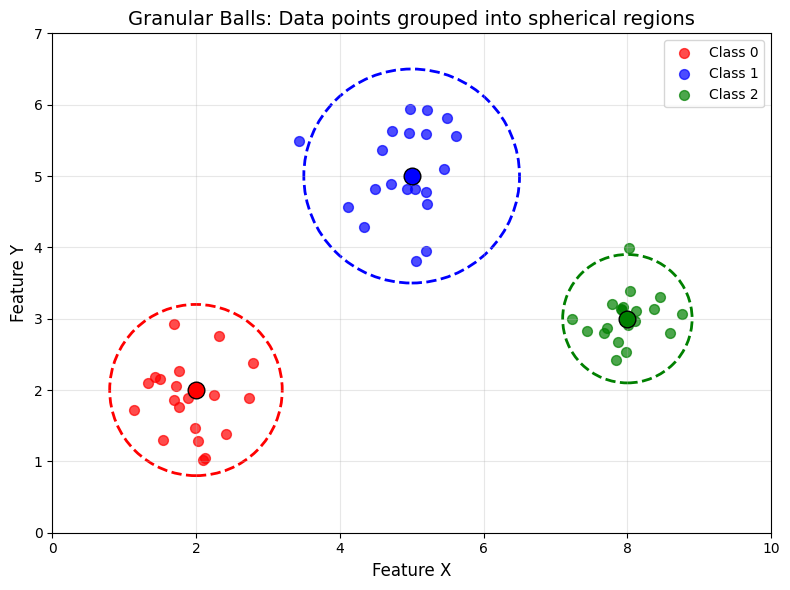

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

# Generate synthetic data points for three classes
np.random.seed(42)
# Ball 1: class 0 (red) centered at (2,2)
points1 = np.random.randn(20,2) * 0.5 + [2,2]
# Ball 2: class 1 (blue) centered at (5,5)
points2 = np.random.randn(20,2) * 0.6 + [5,5]
# Ball 3: class 2 (green) centered at (8,3)
points3 = np.random.randn(20,2) * 0.4 + [8,3]

fig, ax = plt.subplots(figsize=(8,6))

# Plot data points
ax.scatter(points1[:,0], points1[:,1], c='red', s=50, label='Class 0', alpha=0.7)
ax.scatter(points2[:,0], points2[:,1], c='blue', s=50, label='Class 1', alpha=0.7)
ax.scatter(points3[:,0], points3[:,1], c='green', s=50, label='Class 2', alpha=0.7)

# Ball centers
centers = [(2,2), (5,5), (8,3)]
colors = ['red', 'blue', 'green']
radii = [1.2, 1.5, 0.9]

for (cx,cy), r, col in zip(centers, radii, colors):
    circle = Circle((cx,cy), r, fill=False, edgecolor=col, linewidth=2, linestyle='--')
    ax.add_patch(circle)
    ax.plot(cx, cy, marker='o', markersize=12, color=col, markeredgecolor='black', markerfacecolor=col)

ax.set_xlim(0,10)
ax.set_ylim(0,7)
ax.set_xlabel('Feature X', fontsize=12)
ax.set_ylabel('Feature Y', fontsize=12)
ax.set_title('Granular Balls: Data points grouped into spherical regions', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('granular_balls_concept.pdf', dpi=300)
plt.show()

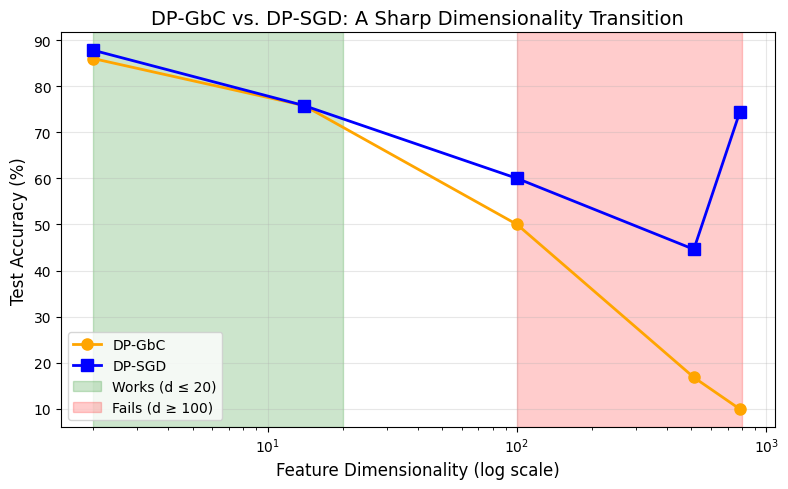

In [16]:
# Data from your experiments (approximate mean accuracies at ε≈4.5)
dimensions = [2, 14, 100, 512, 784]
dp_gbc_acc = [86.0, 75.8, 50.0, 16.8, 9.9]   # estimated 50% at 100D is a guess; adjust if you have real values
dp_sgd_acc = [87.8, 75.8, 60.0, 44.6, 74.5]  # Adult:75.8, CIFAR:44.6, MNIST:74.5

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(dimensions, dp_gbc_acc, 'o-', color='orange', linewidth=2, markersize=8, label='DP‑GbC')
ax.plot(dimensions, dp_sgd_acc, 's-', color='blue', linewidth=2, markersize=8, label='DP‑SGD')
ax.axvspan(2, 20, alpha=0.2, color='green', label='Works (d ≤ 20)')
ax.axvspan(100, 800, alpha=0.2, color='red', label='Fails (d ≥ 100)')
ax.set_xscale('log')
ax.set_xlabel('Feature Dimensionality (log scale)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('DP‑GbC vs. DP‑SGD: A Sharp Dimensionality Transition', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dimensionality_cliff.pdf', dpi=300)
plt.show()

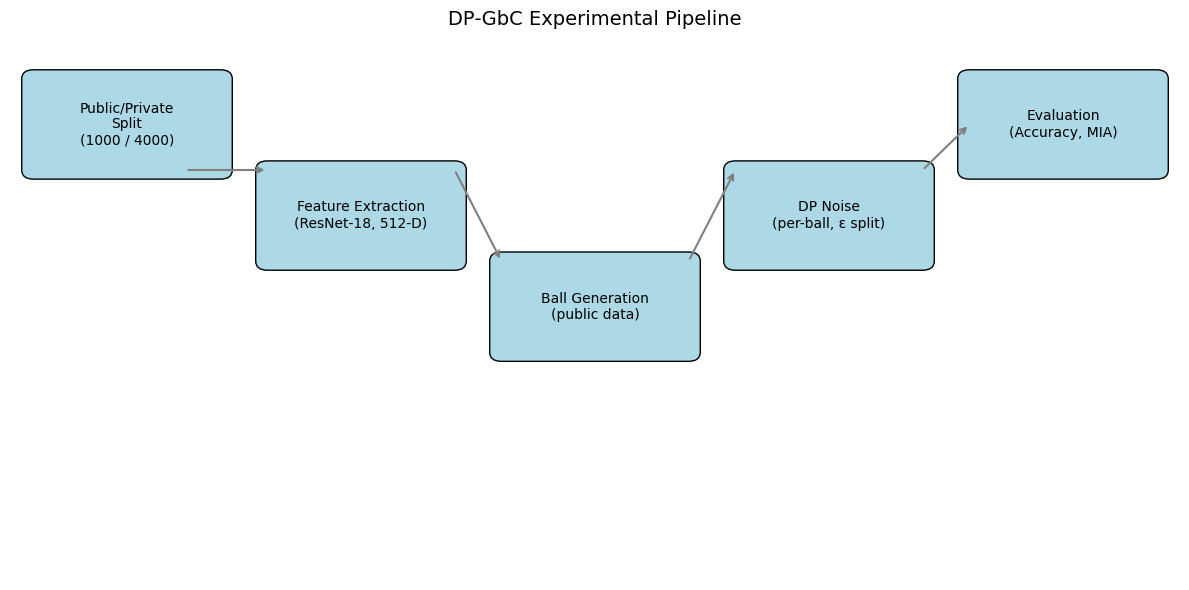

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path

fig, ax = plt.subplots(figsize=(12,6))
ax.set_xlim(0,10)
ax.set_ylim(0,6)
ax.axis('off')

# Blocks
steps = [
    (1,5,"Public/Private\nSplit\n(1000 / 4000)"),
    (3,4,"Feature Extraction\n(ResNet-18, 512-D)"),
    (5,3,"Ball Generation\n(public data)"),
    (7,4,"DP Noise\n(per-ball, ε split)"),
    (9,5,"Evaluation\n(Accuracy, MIA)")
]
for x,y,text in steps:
    rect = patches.FancyBboxPatch((x-0.8, y-0.5), 1.6, 1.0,
                                  boxstyle="round,pad=0.1",
                                  facecolor='lightblue', edgecolor='black')
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=10)

# Arrows
arrows = [(1.5,4.5, 2.2,4.5), (3.8,4.5, 4.2,3.5), (5.8,3.5, 6.2,4.5), (7.8,4.5, 8.2,5.0)]
for x1,y1,x2,y2 in arrows:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title('DP‑GbC Experimental Pipeline', fontsize=14)
plt.tight_layout()
plt.savefig('pipeline.pdf', dpi=300)
plt.show()

In [25]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'pipeline.pdf', 'data', 'granular_balls_concept.pdf', 'dimensionality_cliff.pdf', 'sample_data']


In [26]:
!pwd
!ls -lah

/content
total 80K
drwxr-xr-x 1 root root 4.0K May 31 08:58 .
drwxr-xr-x 1 root root 4.0K May 31 08:49 ..
drwxr-xr-x 4 root root 4.0K May 26 13:31 .config
drwxr-xr-x 4 root root 4.0K May 31 08:57 data
-rw-r--r-- 1 root root  20K May 31 08:58 dimensionality_cliff.pdf
-rw-r--r-- 1 root root  18K May 31 08:58 granular_balls_concept.pdf
-rw-r--r-- 1 root root  17K May 31 08:58 pipeline.pdf
drwxr-xr-x 1 root root 4.0K May 26 13:31 sample_data


In [27]:
from google.colab import files
files.upload()

Saving When_Do_Granular_Ball_Classifiers_Work_Under_Differential_Privacy__A_Dimensionality‑Dependent_Analysis (3).ipynb to When_Do_Granular_Ball_Classifiers_Work_Under_Differential_Privacy__A_Dimensionality‑Dependent_Analysis (3).ipynb


{'When_Do_Granular_Ball_Classifiers_Work_Under_Differential_Privacy__A_Dimensionality‑Dependent_Analysis (3).ipynb': b'{\n  "cells": [\n    {\n      "cell_type": "code",\n      "execution_count": null,\n      "metadata": {\n        "id": "RJTN5CTM7cZ6"\n      },\n      "outputs": [],\n      "source": [\n        "!pip install -q torch torchvision opacus scikit-learn scipy matplotlib"\n      ]\n    },\n    {\n      "cell_type": "code",\n      "source": [\n        "import torch, torchvision, numpy as np, random, math, copy\\n",\n        "from torch import nn\\n",\n        "from torchvision import transforms\\n",\n        "from sklearn.metrics import accuracy_score\\n",\n        "import matplotlib.pyplot as plt\\n",\n        "import sys\\n",\n        "sys.setrecursionlimit(10000)\\n",\n        "\\n",\n        "# Reproducibility (global seed for split)\\n",\n        "SEED = 42\\n",\n        "random.seed(SEED)\\n",\n        "np.random.seed(SEED)\\n",\n        "torch.manual_seed(SEED)\\n",\n 

In [29]:
import json

with open("When_Do_Granular_Ball_Classifiers_Work_Under_Differential_Privacy__A_Dimensionality‑Dependent_Analysis (3).ipynb", "r", encoding="utf-8") as f:
    json.load(f)

print("Notebook JSON is valid")

Notebook JSON is valid
